# Exploratory Data Analysis Pipeline

Aim: Perform reusable EDA, preprocessing, feature selection, PCA, and inference generation for ML laboratory datasets.

## Import Libraries

Import the libraries needed for data handling, statistics, visualization, preprocessing, feature selection, and PCA.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display, Markdown
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

## Configuration

Change only this cell for a different dataset.

In [2]:
DATASET_NAME = globals().get("DATASET_NAME", "Iris")
CSV_PATH = globals().get("CSV_PATH", None)
TARGET_COLUMN = globals().get("TARGET_COLUMN", "species")
OUTPUT_DIRECTORY = globals().get("OUTPUT_DIRECTORY", "eda_output")
TEST_SIZE = globals().get("TEST_SIZE", 0.2)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

## Load Dataset

Load Iris by default, or load a CSV when `CSV_PATH` is provided.

In [3]:
os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)
PLOTS_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "plots")
os.makedirs(PLOTS_DIRECTORY, exist_ok=True)

if CSV_PATH is None:
    iris = load_iris(as_frame=True)
    df = iris.frame.rename(columns={"target": TARGET_COLUMN})
    df[TARGET_COLUMN] = df[TARGET_COLUMN].map(dict(enumerate(iris.target_names)))
else:
    for encoding in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        try:
            df = pd.read_csv(CSV_PATH, encoding=encoding)
            break
        except UnicodeDecodeError:
            continue

print(f"Dataset: {DATASET_NAME}")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())
display(df.sample(min(5, len(df)), random_state=RANDOM_STATE))

Dataset: Iris
Shape: (150, 5)
Rows: 150
Columns: 5


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica
78,6.0,2.9,4.5,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor


## Dataset Information

Inspect column types, summary statistics, and automatically detected feature types.

In [4]:
def is_categorical(series):
    values = series.dropna()
    if values.empty:
        return False
    if pd.api.types.is_object_dtype(series) or isinstance(series.dtype, pd.CategoricalDtype) or pd.api.types.is_bool_dtype(series):
        return True
    unique_count = values.nunique()
    unique_ratio = unique_count / len(values)
    return pd.api.types.is_integer_dtype(series) and (unique_count <= 15 or unique_ratio <= 0.05)

numerical_columns, categorical_columns = [], []
for column in df.columns:
    if column == TARGET_COLUMN:
        continue
    if pd.api.types.is_numeric_dtype(df[column]) and not is_categorical(df[column]):
        numerical_columns.append(column)
    else:
        categorical_columns.append(column)

target_type = "None"
problem_type = None
if TARGET_COLUMN in df.columns:
    target_type = "Categorical" if is_categorical(df[TARGET_COLUMN]) or not pd.api.types.is_numeric_dtype(df[TARGET_COLUMN]) else "Numerical"
    problem_type = "classification" if target_type == "Categorical" else "regression"

df.info()
display(df.describe())
display(df.describe(include="all"))
print(f"Numerical features: {len(numerical_columns)}")
print(f"Categorical features: {len(categorical_columns)}")
print(f"Target type: {target_type}")
print(f"ML task: {problem_type}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


Numerical features: 4
Categorical features: 0
Target type: Categorical
ML task: classification


## Data Integrity Checks

Check duplicates, missing values, unique values, and constant columns.

In [5]:
missing_counts = df.isna().sum().astype(int)
missing_percentages = (df.isna().mean() * 100).round(2)
unique_values = df.nunique(dropna=True).astype(int)
duplicate_rows = int(df.duplicated().sum())
constant_columns = unique_values[unique_values <= 1].index.tolist()

integrity_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": missing_counts,
    "missing_%": missing_percentages,
    "unique_values": unique_values,
    "constant": [col in constant_columns for col in df.columns],
})

print(f"Duplicate rows: {duplicate_rows}")
print(f"Constant columns: {constant_columns if constant_columns else 'None'}")
display(integrity_table)

Duplicate rows: 1
Constant columns: None


,dtype,missing_count,missing_%,unique_values,constant
sepal length (cm),float64,0,0.0,35,False
sepal width (cm),float64,0,0.0,23,False
petal length (cm),float64,0,0.0,43,False
petal width (cm),float64,0,0.0,22,False
species,object,0,0.0,3,False


## Missing Value Analysis

Visualize missing values and display the missing percentage for each column.

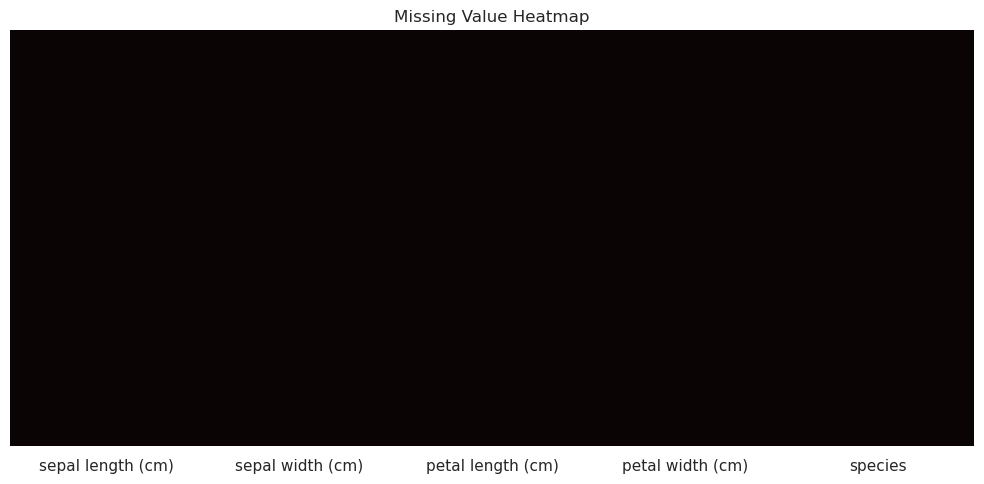

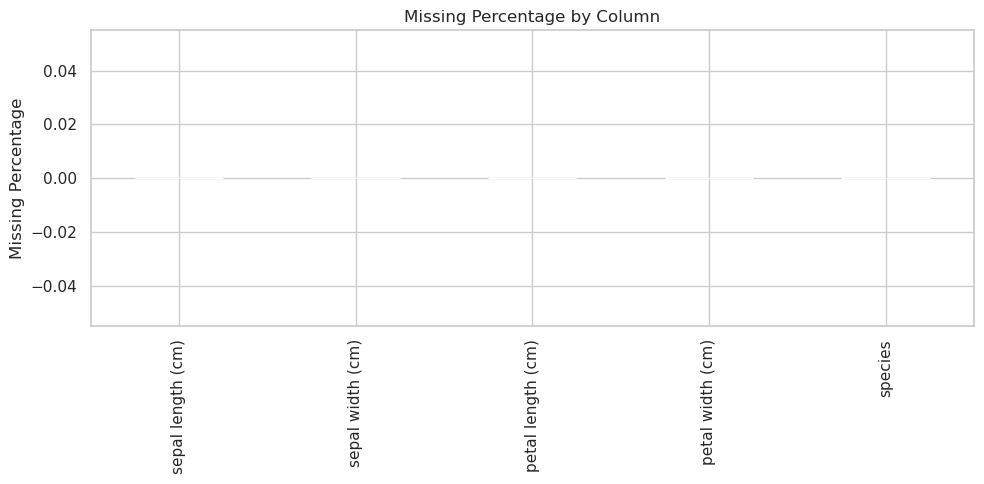

,column,missing_%
0,sepal length (cm),0.0
1,sepal width (cm),0.0
2,petal length (cm),0.0
3,petal width (cm),0.0
4,species,0.0


In [6]:
missing_table = missing_percentages.sort_values(ascending=False).reset_index()
missing_table.columns = ["column", "missing_%"]

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="mako")
plt.title("Missing Value Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIRECTORY, "missing_heatmap.png"), bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
missing_percentages.sort_values(ascending=False).plot(kind="bar", color="#d97706")
plt.ylabel("Missing Percentage")
plt.title("Missing Percentage by Column")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIRECTORY, "missing_bar.png"), bbox_inches="tight")
plt.show()

display(missing_table)

## Outlier Detection

Detect numerical outliers using IQR and Z-score methods.

In [7]:
outlier_rows = []
for column in numerical_columns:
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    std = values.std(ddof=0)
    z_scores = ((values - values.mean()) / std).abs() if std > 0 else pd.Series(0, index=values.index)
    outlier_rows.append({
        "feature": column,
        "iqr_lower": round(lower, 4),
        "iqr_upper": round(upper, 4),
        "iqr_outliers": int(((values < lower) | (values > upper)).sum()),
        "z_score_outliers": int((z_scores > 3).sum()),
    })

outlier_table = pd.DataFrame(outlier_rows)
display(outlier_table)
for _, row in outlier_table.iterrows():
    print(f"{row['feature']}: IQR={row['iqr_outliers']}, Z-score={row['z_score_outliers']}")

,feature,iqr_lower,iqr_upper,iqr_outliers,z_score_outliers
0,sepal length (cm),3.15,8.35,0,0
1,sepal width (cm),2.05,4.05,4,1
2,petal length (cm),-3.65,10.35,0,0
3,petal width (cm),-1.95,4.05,0,0


sepal length (cm): IQR=0, Z-score=0
sepal width (cm): IQR=4, Z-score=1
petal length (cm): IQR=0, Z-score=0
petal width (cm): IQR=0, Z-score=0


## Statistical Analysis

Run Shapiro-Wilk and target-specific statistical tests based on the detected task type.

In [8]:
normality_results = []
for column in numerical_columns:
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    if len(values) >= 3:
        sample = values.sample(5000, random_state=42) if len(values) > 5000 else values
        stat, p_value = stats.shapiro(sample)
        normality_results.append({"feature": column, "test": "Shapiro", "statistic": stat, "p_value": p_value, "normal": p_value > 0.05})
normality_table = pd.DataFrame(normality_results)
display(normality_table)

target_test_results = []
if TARGET_COLUMN in df.columns and problem_type == "classification":
    target = df[TARGET_COLUMN]
    for column in numerical_columns:
        groups = [pd.to_numeric(df.loc[target == label, column], errors="coerce").dropna() for label in target.dropna().unique()]
        groups = [group for group in groups if len(group) >= 2]
        if len(groups) >= 2:
            stat, p_value = stats.f_oneway(*groups)
            target_test_results.append({"feature": column, "test": "ANOVA", "statistic": stat, "p_value": p_value})
    for column in categorical_columns:
        table = pd.crosstab(df[column], target)
        if table.shape[0] >= 2 and table.shape[1] >= 2:
            stat, p_value, dof, _ = stats.chi2_contingency(table)
            target_test_results.append({"feature": column, "test": "Chi-square", "statistic": stat, "p_value": p_value})
elif TARGET_COLUMN in df.columns and problem_type == "regression":
    target = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
    for column in numerical_columns:
        pair = pd.DataFrame({"x": pd.to_numeric(df[column], errors="coerce"), "y": target}).dropna()
        if len(pair) >= 3:
            pearson_stat, pearson_p = stats.pearsonr(pair["x"], pair["y"])
            spearman_stat, spearman_p = stats.spearmanr(pair["x"], pair["y"])
            target_test_results += [
                {"feature": column, "test": "Pearson", "statistic": pearson_stat, "p_value": pearson_p},
                {"feature": column, "test": "Spearman", "statistic": spearman_stat, "p_value": spearman_p},
            ]

target_tests_table = pd.DataFrame(target_test_results)
display(target_tests_table)

,feature,test,statistic,p_value,normal
0,sepal length (cm),Shapiro,0.976090,1.018116e-02,False
1,sepal width (cm),Shapiro,0.984918,1.011543e-01,True
2,petal length (cm),Shapiro,0.876268,7.412263e-10,False
3,petal width (cm),Shapiro,0.901835,1.680465e-08,False


,feature,test,statistic,p_value
0,sepal length (cm),ANOVA,119.264502,1.669669e-31
1,sepal width (cm),ANOVA,49.160040,4.492017e-17
2,petal length (cm),ANOVA,1180.161182,2.856777e-91
3,petal width (cm),ANOVA,960.007147,4.169446e-85


## Correlation Analysis

Display correlations among numerical features and identify highly correlated feature pairs.

**Pearson Correlation Matrix**

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


**Spearman Correlation Matrix**

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.166778,0.881898,0.834289
sepal width (cm),-0.166778,1.000000,-0.309635,-0.289032
petal length (cm),0.881898,-0.309635,1.000000,0.937667
petal width (cm),0.834289,-0.289032,0.937667,1.000000


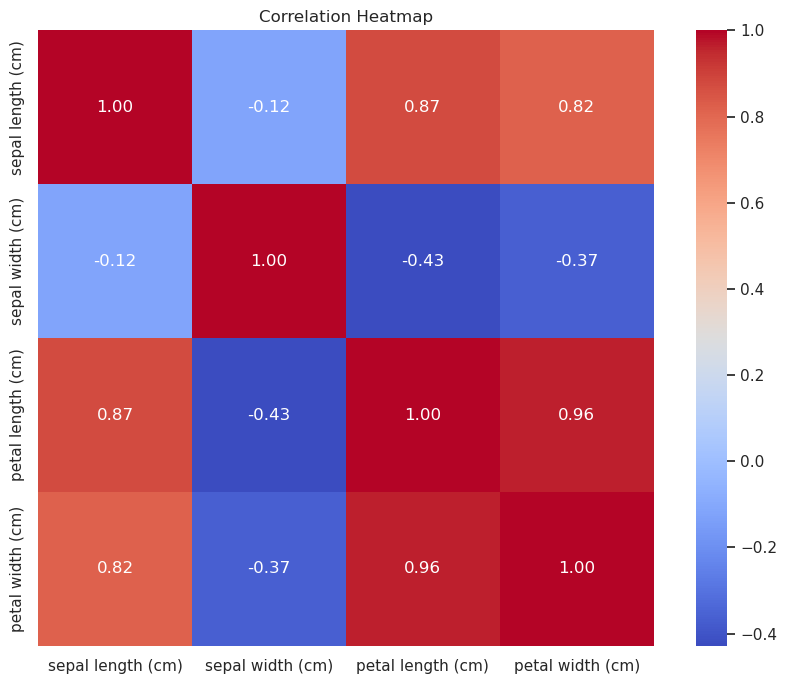

Highly correlated pairs: 3


,feature_1,feature_2,correlation
0,sepal length (cm),petal length (cm),0.871754
1,sepal length (cm),petal width (cm),0.817941
2,petal length (cm),petal width (cm),0.962865


In [9]:
correlation_matrix = df[numerical_columns].corr(method="pearson") if len(numerical_columns) >= 2 else pd.DataFrame()
spearman_matrix = df[numerical_columns].corr(method="spearman") if len(numerical_columns) >= 2 else pd.DataFrame()
display(Markdown("**Pearson Correlation Matrix**"))
display(correlation_matrix)
display(Markdown("**Spearman Correlation Matrix**"))
display(spearman_matrix)

if not correlation_matrix.empty:
    plt.figure(figsize=(9, 7))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIRECTORY, "correlation_heatmap.png"), bbox_inches="tight")
    plt.show()

high_corr_pairs = []
for i, col1 in enumerate(correlation_matrix.columns):
    for col2 in correlation_matrix.columns[i + 1:]:
        corr = correlation_matrix.loc[col1, col2]
        if abs(corr) >= 0.80:
            high_corr_pairs.append({"feature_1": col1, "feature_2": col2, "correlation": corr})
high_corr_table = pd.DataFrame(high_corr_pairs)
print(f"Highly correlated pairs: {len(high_corr_table)}")
display(high_corr_table)

## Target Analysis

Use grouped boxplots for classification and scatterplots for regression.

,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


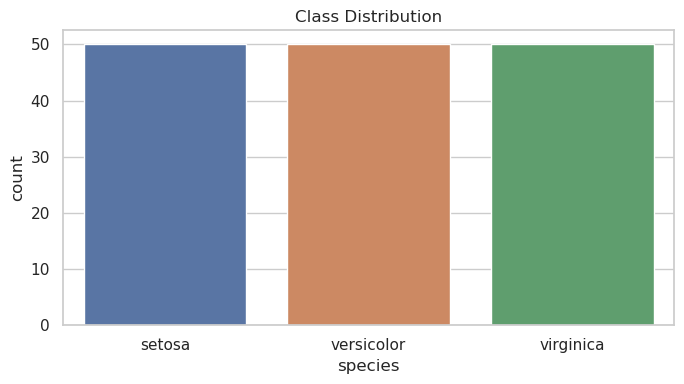

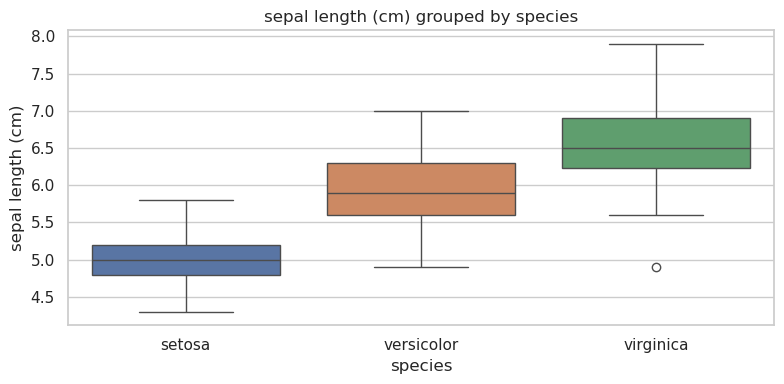

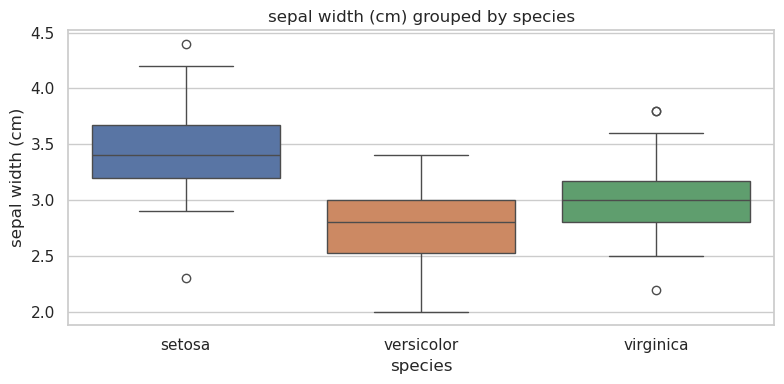

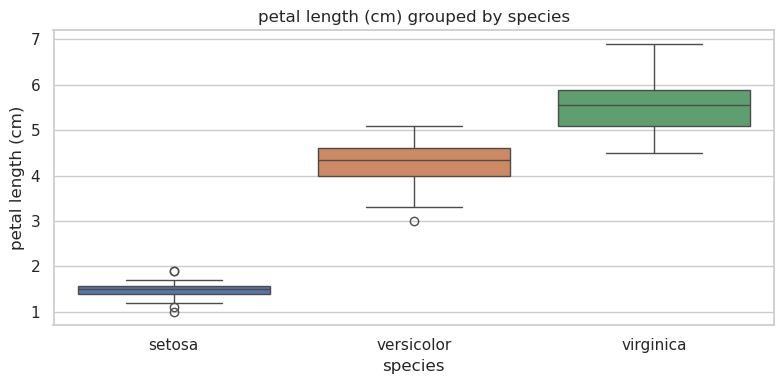

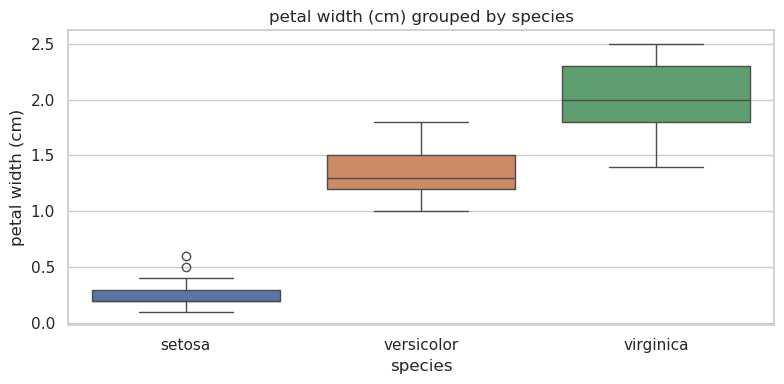

In [10]:
if TARGET_COLUMN in df.columns and problem_type == "classification":
    class_distribution = df[TARGET_COLUMN].value_counts().reset_index()
    class_distribution.columns = [TARGET_COLUMN, "count"]
    display(class_distribution)
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=TARGET_COLUMN, hue=TARGET_COLUMN, legend=False)
    plt.title("Class Distribution")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIRECTORY, "class_distribution.png"), bbox_inches="tight")
    plt.show()
    for column in numerical_columns[:4]:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=TARGET_COLUMN, y=column, hue=TARGET_COLUMN, legend=False)
        plt.title(f"{column} grouped by {TARGET_COLUMN}")
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIRECTORY, f"target_boxplot_{column}.png"), bbox_inches="tight")
        plt.show()
elif TARGET_COLUMN in df.columns and problem_type == "regression":
    for column in numerical_columns[:4]:
        plt.figure(figsize=(7, 5))
        sns.regplot(data=df, x=column, y=TARGET_COLUMN, scatter_kws={"alpha": 0.7})
        plt.title(f"{column} vs {TARGET_COLUMN}")
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIRECTORY, f"target_regplot_{column}.png"), bbox_inches="tight")
        plt.show()
else:
    print("Target analysis skipped because no valid target column was found.")

## Data Preprocessing

Apply train-test split, imputation, one-hot encoding, and standard scaling without data leakage.

In [11]:
X = df.drop(columns=[TARGET_COLUMN]) if TARGET_COLUMN in df.columns else df.copy()
y = df[TARGET_COLUMN].copy() if TARGET_COLUMN in df.columns else None

if y is not None:
    valid_index = y.dropna().index
    X, y = X.loc[valid_index].copy(), y.loc[valid_index].copy()

stratify = y if problem_type == "classification" and y is not None and y.value_counts().min() >= 2 else None
if y is None:
    X_train, X_test = train_test_split(X, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    y_train = y_test = None
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify)

x_num = [col for col in numerical_columns if col in X.columns]
x_cat = [col for col in categorical_columns if col in X.columns]
X_train_processed, X_test_processed = X_train.copy(), X_test.copy()
encoded_features = []

if x_num:
    num_imputer = SimpleImputer(strategy="median")
    X_train_processed.loc[:, x_num] = num_imputer.fit_transform(X_train_processed[x_num])
    X_test_processed.loc[:, x_num] = num_imputer.transform(X_test_processed[x_num])
    scaler = StandardScaler()
    X_train_processed.loc[:, x_num] = scaler.fit_transform(X_train_processed[x_num])
    X_test_processed.loc[:, x_num] = scaler.transform(X_test_processed[x_num])

if x_cat:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train_processed.loc[:, x_cat] = cat_imputer.fit_transform(X_train_processed[x_cat])
    X_test_processed.loc[:, x_cat] = cat_imputer.transform(X_test_processed[x_cat])
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
    train_encoded = encoder.fit_transform(X_train_processed[x_cat])
    test_encoded = encoder.transform(X_test_processed[x_cat])
    encoded_features = encoder.get_feature_names_out(x_cat).tolist()
    X_train_processed = pd.concat([X_train_processed.drop(columns=x_cat), pd.DataFrame(train_encoded, columns=encoded_features, index=X_train_processed.index)], axis=1)
    X_test_processed = pd.concat([X_test_processed.drop(columns=x_cat), pd.DataFrame(test_encoded, columns=encoded_features, index=X_test_processed.index)], axis=1)

feature_names = X_train_processed.columns.tolist()
preprocessor = {
    "numerical_columns": x_num,
    "categorical_columns": x_cat,
    "encoded_features": encoded_features,
    "num_imputer": globals().get("num_imputer", None),
    "cat_imputer": globals().get("cat_imputer", None),
    "scaler": globals().get("scaler", None),
    "encoder": globals().get("encoder", None),
}
X_train_raw, X_test_raw = X_train.copy(), X_test.copy()
X_train, X_test = X_train_processed.copy(), X_test_processed.copy()

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")
print(f"Encoded features: {len(encoded_features)}")
display(X_train.head())

Training shape: (120, 4)
Testing shape: (30, 4)
Encoded features: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
8,-1.721568,-0.332101,-1.345722,-1.323276
106,-1.124492,-1.227655,0.414505,0.651763
76,1.144395,-0.555990,0.584850,0.256755
9,-1.124492,0.115676,-1.288941,-1.454945
89,-0.408002,-1.227655,0.130598,0.125086


## Feature Selection

Use SelectKBest and Mutual Information to rank features with respect to the target.

In [12]:
feature_selection_table = pd.DataFrame()
if y_train is not None and not X_train_processed.empty:
    score_func = f_classif if problem_type == "classification" else f_regression
    mi_func = mutual_info_classif if problem_type == "classification" else mutual_info_regression
    selector = SelectKBest(score_func=score_func, k="all")
    selector.fit(X_train_processed, y_train)
    mi_scores = mi_func(X_train_processed, y_train, random_state=42)
    feature_selection_table = pd.DataFrame({
        "feature": X_train_processed.columns,
        "select_k_best_score": selector.scores_,
        "p_value": selector.pvalues_,
        "mutual_information": mi_scores,
    }).sort_values("mutual_information", ascending=False)
    display(feature_selection_table)
else:
    print("Feature selection skipped because no target column was available.")

,feature,select_k_best_score,p_value,mutual_information
3,petal width (cm),803.214088,4.569528e-69,1.003849
2,petal length (cm),948.890381,4.915264e-73,0.985075
0,sepal length (cm),100.965923,3.330785e-26,0.585014
1,sepal width (cm),36.030577,6.421523e-13,0.204446


## PCA

Project processed features into two principal components and display explained variance.

,component,explained_variance_ratio
0,PC1,0.7268
1,PC2,0.2307


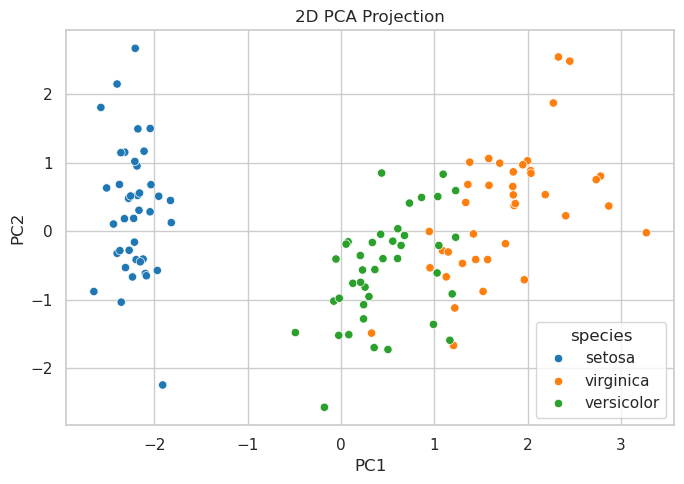

In [13]:
pca_variance = []
if X_train_processed.shape[1] >= 2:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_projection = pca.fit_transform(X_train_processed)
    pca_variance = pca.explained_variance_ratio_.round(4).tolist()
    pca_df = pd.DataFrame({"PC1": pca_projection[:, 0], "PC2": pca_projection[:, 1]})
    if y_train is not None:
        pca_df[TARGET_COLUMN] = y_train.values
    display(pd.DataFrame({"component": ["PC1", "PC2"], "explained_variance_ratio": pca_variance}))
    plt.figure(figsize=(7, 5))
    if y_train is not None and problem_type == "classification":
        sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COLUMN, palette="tab10")
    else:
        sns.scatterplot(data=pca_df, x="PC1", y="PC2")
    plt.title("2D PCA Projection")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIRECTORY, "pca_2d_projection.png"), bbox_inches="tight")
    plt.show()
else:
    print("PCA skipped because fewer than two processed features are available.")

## Inference Summary

Summarize the key findings needed for the observation note.

In [14]:
suggested_models = []
if problem_type == "classification":
    suggested_models = ["Logistic Regression", "Decision Tree", "Random Forest", "KNN", "Naive Bayes", "SVM"]
elif problem_type == "regression":
    suggested_models = ["Linear Regression", "Ridge", "Lasso", "Decision Tree Regressor", "Random Forest Regressor", "SVR"]

summary_points = [
    f"Dataset contains {df.shape[0]} samples and {df.shape[1]} columns.",
    f"Detected {len(numerical_columns)} numerical features and {len(categorical_columns)} categorical features.",
    f"Target column `{TARGET_COLUMN}` is treated as {target_type}; task type is {problem_type}.",
    f"Duplicate rows: {duplicate_rows}.",
    f"Columns with missing values: {int((missing_counts > 0).sum())}.",
    f"Highly correlated feature pairs: {len(high_corr_table)}.",
    f"Constant features: {constant_columns if constant_columns else 'None'}.",
    f"Suggested models: {', '.join(suggested_models) if suggested_models else 'Not applicable'}.",
]

for point in summary_points:
    print(point)

Dataset contains 150 samples and 5 columns.
Detected 4 numerical features and 0 categorical features.
Target column `species` is treated as Categorical; task type is classification.
Duplicate rows: 1.
Columns with missing values: 0.
Highly correlated feature pairs: 3.
Constant features: None.
Suggested models: Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, SVM.


## Save Markdown Report

Save a concise report using the results already computed in the notebook.

In [15]:
report_path = os.path.join(OUTPUT_DIRECTORY, "eda_report.md")
report_lines = [
    "# EDA Report\n",
    f"## Dataset\n- Name: {DATASET_NAME}\n- Shape: {df.shape}\n- Target: {TARGET_COLUMN}\n- Task: {problem_type}\n",
    "## Integrity\n",
    f"- Duplicate rows: {duplicate_rows}\n- Missing-value columns: {int((missing_counts > 0).sum())}\n- Constant columns: {constant_columns if constant_columns else 'None'}\n",
    "## Feature Types\n",
    f"- Numerical features: {len(numerical_columns)}\n- Categorical features: {len(categorical_columns)}\n",
    "## Outliers\n",
    outlier_table.to_markdown(index=False) if not outlier_table.empty else "No numerical outlier table available.",
    "\n## Feature Selection\n",
    feature_selection_table.head(10).to_markdown(index=False) if not feature_selection_table.empty else "Feature selection skipped.",
    "\n## Inference Summary\n",
    "\n".join(f"- {point}" for point in summary_points),
]

with open(report_path, "w", encoding="utf-8") as report_file:
    report_file.write("\n".join(report_lines))

print(f"Report saved to: {report_path}")
print(f"Plots saved to: {PLOTS_DIRECTORY}")

Report saved to: eda_output/eda_report.md
Plots saved to: eda_output/plots
